# Coherence Score Analysis - Full Filtered Dataset (Google Colab)

This notebook computes gensim c_v coherence scores for the full filtered Reddit corpus
(greenwashing_dataset_filtered.csv) to select the optimal number of LDA topics.
Run on Google Colab (Python 3.12) due to gensim compatibility issues with Python 3.14+.

In [1]:
import pandas as pd
import numpy as np
import gensim
import matplotlib.pyplot as plt
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 39.2 MB/s eta 0:00:00


In [2]:
from google.colab import files
uploaded = files.upload()

Saving greenwashing_dataset_filtered.csv to greenwashing_dataset_filtered.csv


In [3]:
df = pd.read_csv('greenwashing_dataset_filtered.csv')
df.head()


,Post_id,Timestamp,Text,Score,subreddit,content_type,text_length,year
0,1gr3og,2013-06-20 21:04:00,"The term ""greenwashing"" was originally used to...",2.0,GreenwashingSubreddit,post,1962,2013
1,5x1vz1,2017-03-02 07:19:00,A critical look behind the green/sustainable f...,1.0,GreenwashingSubreddit,post,418,2017
2,cn3g3p,2019-08-07 09:13:00,I work for TerraCycle with Tom Szaky - our CEO...,2.0,GreenwashingSubreddit,post,2335,2019
3,etnfpf,2020-01-25 06:46:00,South China Morning Post: Fashion is still gre...,3.0,GreenwashingSubreddit,post,194,2020
4,g11ydz,2020-04-14 08:44:00,\nHi everyone! I am currently writing my Mas...,2.0,GreenwashingSubreddit,post,664,2020


In [4]:
import re
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

custom_stopwords = {
    'people', 'one', 'think', 'thing', 'use', 'make', 'way', 'even',
    'dont', 'thats', 'isnt', 'doesnt', 'cant', 'im', 'youre', 'theyre', 'arent',
    'u', 'ye', 'etc', 'really', 'still', 'much', 'many', 'lot', 'well',
    'good', 'great', 'better', 'got', 'put', 'go', 'come', 'take', 'try',
    'say', 'feel', 'mean', 'seem', 'look', 'start', 'end', 'keep', 'would',
    'want', 'need', 'know', 'help', 'find', 'work', 'used', 'using',
    'something', 'anything', 'everything', 'nothing', 'someone', 'like', 'get',
    'also', 'back', 'around', 'first', 'every', 'never', 'always',
    'maybe', 'probably', 'though', 'already', 'enough', 'little',   'thing',
    'stuff', 'see', 'go', 'going', 'come', 'sure', 'actually', 'u', 'co',
    'right', 'yes', 'yeah', 'u', 'me', 'said', 'saying', 'didnt', 'wont',
    'thing', 'things', 'ive', 'u', 'time', 'point', 'thank', 'come', 'making'
}
stop_words_extended = stop_words | custom_stopwords

def preprocess_text(text):
    if pd.isna(text):
        return ''
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words_extended]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

df['text_clean'] = df['Text'].apply(preprocess_text)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [5]:
texts = [text.split() for text in df['text_clean']]
dictionary = Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

print(f"Vocabulary size: {len(dictionary)}")
print(f"Corpus size: {len(corpus)}")

Vocabulary size: 38849
Corpus size: 27851


n_topics=2: coherence=0.5388
n_topics=3: coherence=0.5450
n_topics=4: coherence=0.5363
n_topics=5: coherence=0.5107
n_topics=6: coherence=0.5188
n_topics=7: coherence=0.5200
n_topics=8: coherence=0.5634
n_topics=9: coherence=0.5569
n_topics=10: coherence=0.5575


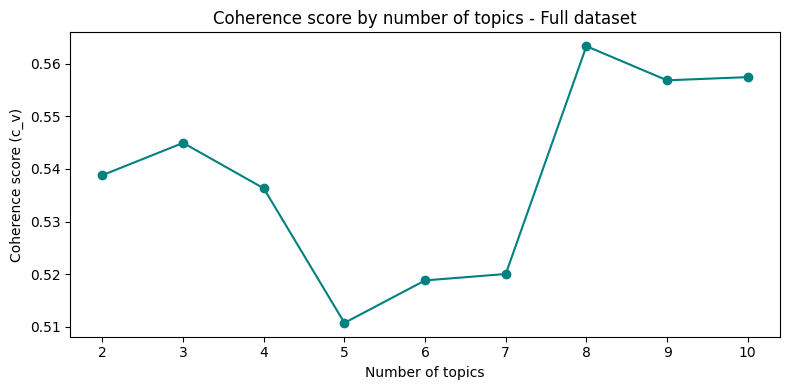

In [6]:
coherence_scores = []
n_topics_range = range(2, 11)

for n in n_topics_range:
    lda_model = gensim.models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=n,
        random_state=42,
        passes=10
    )
    coherence_model = CoherenceModel(
        model=lda_model,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    )
    score = coherence_model.get_coherence()
    coherence_scores.append(score)
    print(f"n_topics={n}: coherence={score:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(n_topics_range, coherence_scores, marker='o', color='teal')
plt.xlabel('Number of topics')
plt.ylabel('Coherence score (c_v)')
plt.title('Coherence score by number of topics - Full dataset')
plt.tight_layout()
plt.show()